# Classification

## 1. The MNIST Dataset

**MNIST** is a set of 70,000 images of handwritten digits (0-9). It's so famous that it's called the "hello world" of machine learning.

- Each image is **28 × 28 pixels**
- Each pixel has a value from 0 (black) to 255 (white)
- 28 × 28 = **784 features** per image

Let's download it using Scikit-Learn:

In [1]:
import joblib
from pathlib import Path
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", as_frame=False)

project_root = Path.cwd().parents[2]
raw_dir = project_root / "data" / "raw"

joblib.dump(mnist, raw_dir / "mnist.joblib")

['c:\\Users\\Usuario\\Desktop\\PracticeProgramming\\MachineLearning\\Hands-OnMachineLearningwithScikit-LearnandPyTorch-Aur-lienG-ron\\data\\raw\\mnist.joblib']

In [2]:
mnist

{'data': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int64),
 'target': array(['5', '0', '4', ..., '4', '5', '6'], dtype=object),
 'frame': None,
 'categories': {'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']},
 'feature_names': ['pixel1',
  'pixel2',
  'pixel3',
  'pixel4',
  'pixel5',
  'pixel6',
  'pixel7',
  'pixel8',
  'pixel9',
  'pixel10',
  'pixel11',
  'pixel12',
  'pixel13',
  'pixel14',
  'pixel15',
  'pixel16',
  'pixel17',
  'pixel18',
  'pixel19',
  'pixel20',
  'pixel21',
  'pixel22',
  'pixel23',
  'pixel24',
  'pixel25',
  'pixel26',
  'pixel27',
  'pixel28',
  'pixel29',
  'pixel30',
  'pixel31',
  'pixel32',
  'pixel33',
  'pixel34',
  'pixel35',
  'pixel36',
  'pixel37',
  'pixel38',
  'pixel39',
  'pixel40',
  'pixel41',
  'pixel42',
  'pixel43',
  'pixel44',
  'pixel45',
  'pixel46

In [3]:
X, y = mnist.data, mnist.target

In [4]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (70000, 784)
Shape of y: (70000,)


**Reading the result:**
- `X` has the form `(70000, 784)`: 70,000 images, each with 784 pixels
- `y` has the form `(70000,)`: 70,000 labels (the digits from 0 to 9)

## Anatomía de una imagen

In [5]:
import numpy as np

np.set_printoptions(linewidth=200)
X_28x28 = X[2].reshape(28, 28)

In [6]:
X_28x28

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  67, 232,  39,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,  62,  81,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0

In [7]:
y[2]

'4'

## 2. Exploring and Visualizing Data

Let's look at an image. To do this:
1. Take a vector of 784 values
2. Reshape it into a 28 × 28 matrix
3. Display it using Matplotlib

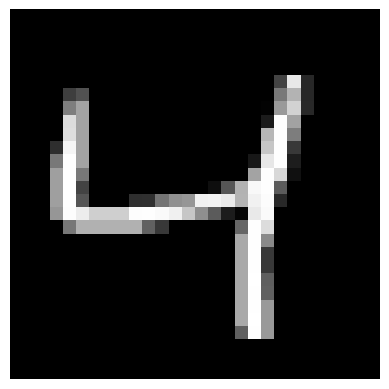

In [8]:
import matplotlib.pyplot as plt

plt.imshow(X_28x28, cmap="gray")
plt.axis("off")
plt.show()

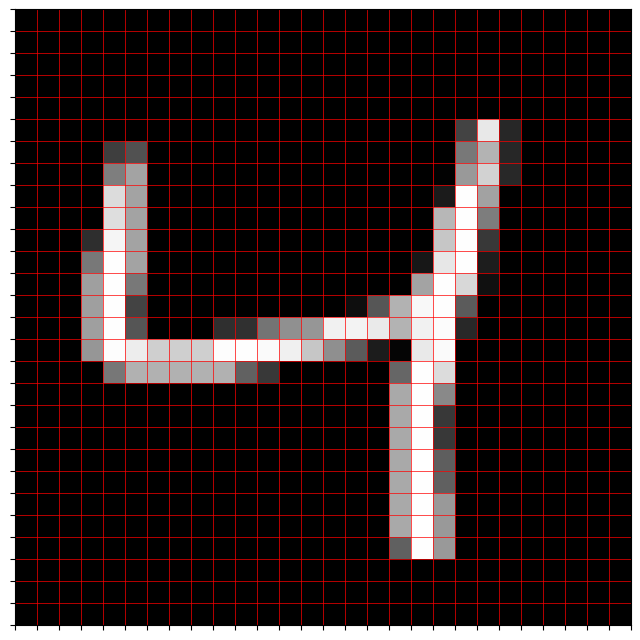

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 8))

plt.imshow(X_28x28, cmap="gray")

plt.xticks(np.arange(-0.5, 28, 1), [])
plt.yticks(np.arange(-0.5, 28, 1), [])

plt.grid(color='red', linestyle='-', linewidth=0.5)

plt.show()

## 3. Split into training/test data

A golden rule in Machine Learning: **separate the data into training and test data BEFORE looking at it in detail**. This prevents bias when designing the model.

The MNIST dataset is already split:
- First **60,000** images → training
- Last **10,000** images → test

In [10]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Train: (60000, 784)
Test:  (10000, 784)


**Bonus:** The dataset is already shuffled. This is important because:
1. It ensures that the cross-validation partitions are balanced.
2. Some algorithms perform poorly if they receive many similar examples in succession.

## 4. Training a Binary Classifier: The "5-Detector"

To simplify, we'll train a model that only distinguishes between two classes:
- **Is a 5** → `True`
- **Is not a 5** → `False`

This is called **binary classification**.

First, we create the binary labels:

In [11]:
y_train_5 = (y_train == '5') # True if it's a 5, False otherwise
y_test_5 = (y_test == '5')

print("Number of 5s in train:", sum(y_train_5))
print("Number of non-5s in train:", sum(~y_train_5))

Number of 5s in train: 5421
Number of non-5s in train: 54579


**Pay attention to this proportion**, it's KEY to understanding what comes next. Only about **10%** of the images are 5s.

### We train the SGD model

The **SGDClassifier** (Stochastic Gradient Descent) is a good classifier to start with. It's efficient with large datasets because it processes instances one by one.

In [12]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


### Let's try a prediction

Does the model recognize `some_digit` (which we know is a 5) as a 5?

In [13]:
sgd_clf.predict([X[1]])

array([False])

It returned 'True'! The model says "yes, this is a 5." It was right.

But **a correct prediction tells us nothing about the model as a whole**. We need to evaluate it with many images.

## 5. Measuring Performance

### 5.1. What is Accuracy?

**Accuracy = correct predictions / total predictions**

If the model correctly predicts 95 out of 100 images → 95% accuracy. It's the most intuitive metric, but as we'll see, **it can be very misleading**.

### 5.2. What is Cross-Validation?

Cross-validation with **k folds**. With `cv=3`:

1. We divide the 60,000 data points into 3 equal parts (A, B, C of 20,000 each)
2. **Round 1:** We train with A+B, evaluate with C → one accuracy
3. **Round 2:** We train with A+C, evaluate with B → another accuracy
4. **Round 3:** We train with B+C, evaluate with A → another accuracy

We obtain 3 measurements, giving us a more reliable idea of ​​the actual performance.

In [14]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

**Result: Around 95% on each fold.** Sounds amazing!

Before we celebrate, let's do something to verify...

## 6. The Dummy Classifier Trick

### What is a Dummy Classifier?

It's a classifier that's intentionally "dumb." It doesn't learn real patterns; it simply applies a trivial rule.

By default, its strategy is: "I always predict the most frequent class."

### Why create one?

To have a minimum baseline for comparison. The key question is:

> "Is my 'smart' model really better than doing nothing?"

### Let's look at the code line by line

In [15]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))  # print: False

False


### Deconstructing the Code

**`dummy_clf = DummyClassifier()`**
Creates an empty classifier. It hasn't learned anything yet.

**`dummy_clf.fit(X_train, y_train_5)`**
"Trains" it, but only does ONE thing: counts how many `True` and `False` values ​​are in `y_train_5`:
- True (it's a 5): ~6,000
- False (it's not a 5): ~54,000

Decides: "False is the most common → from now on I'll answer False to EVERYTHING."

**It doesn't look at any pixels.** It only counts labels.

**`dummy_clf.predict(X_train)`**
We ask it to predict the 60,000 images. It returns a list of 60,000 `False` values. Even if we pass it a clear 5, it returns `False`. Even if we pass it a 0, it returns `False`. **Always False.**

**`any(...)`**
Question: *"Is there at least one True in this list?"*. Since everything is False, it returns **False**.

**Printed result: `False`** → confirms that the Dummy **NEVER detects a 5**, not even once.

### Now let's evaluate its accuracy with cross-validation

In [16]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

## 7. Why Accuracy Can Be Misleading with Imbalanced Datasets

### The Surprising Result

| Model                  | Accuracy | Detects 5s? |
| ---------------------- | -------- | ----------- |
| Dummy (does nothing)   | **~90%** | Never       |
| SGD (actually trained) | **~95%** | Sometimes   |
| Perfect model          | 100%     | Always      |

### How Can the Dummy Achieve 90% Accuracy Without Detecting Any 5s?

Remember the dataset distribution:

* **~10%** of the images are 5s.
* **~90%** of the images are NOT 5s.

If the Dummy classifier predicts "not a 5" for every image:

* For the **~90% of images that are not 5s**, it is correct.
* For the **~10% of images that are 5s**, it is wrong.

→ It gets about 90% of the predictions correct without learning anything at all.

### Why Isn't It 100%?

It would only achieve 100% accuracy if there were no 5s in the dataset. Since about 10% of the images are actually 5s, the Dummy classifier misclassifies all of them. That's why its accuracy is around 90%, not 100%.

### The Uncomfortable Conclusion

Your "intelligent" model achieves 95% accuracy, but a model that does absolutely nothing achieves 90%.

**The real improvement is only about 5 percentage points over a model that doesn't even look at the images.**

> **This is what an imbalanced dataset means:** one class appears much more frequently than the other. When this happens, accuracy can be very high even for models that are practically useless.

### Real-World Cases Where This Becomes Catastrophic

* **Cancer detection:** If only 1% of patients have cancer, predicting "healthy" for everyone yields **99% accuracy**... while missing every patient who actually has cancer.
* **Fraud detection:** If only 0.1% of transactions are fraudulent, predicting "legitimate" for every transaction yields **99.9% accuracy**... while failing to detect any fraud.
* **Spam detection:** If only 5% of emails are spam, predicting "not spam" for every email yields **95% accuracy**... while your inbox fills up with spam.

In all these situations, **the minority class is the one we actually care about detecting**, and accuracy gives us a false sense of success.